In [23]:
# -*- coding: utf-8 -*-
"""Trust_Code.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/17DSuF9ZrqL4DH1r_6VzRa8hyMI32UTFT
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Simulation parameters

ENGY=[50, 200] # Energy range in Watt-hrs
LONG=[0, 100] # Longitude 10 km
LAT= [0, 100] # Latitude 10 km
ALT=[5, 20] # Altitude 0.5 km ie 500 m

#Inital reputation score is based on below resources
clock_speed_range=[5, 26] # Clock speed is from 5 to 15 MHz
memory_range=[2, 17] #RAM size is 2 to 16 GB
power_consumption_range = [100, 120]

# Total number of trails
TRIALS = 100
ITERATIONS = 100

# Communication parameters
FREQUENCY = 2.4e9  # Frequency in Hz (2.4 GHz for WiFi)
BANDWIDTH = 20e6  # Bandwidth in Hz (20 MHz)
TRANSMISSION_POWER = 1  # Transmission power in Watts
NOISE_POWER = 1e-9  # Noise power in Watts (assumed)
SPEED_OF_LIGHT = 3e8  # Speed of light in meters per second
r=0.7 # Reputation weight
d=0.3 # Data Rate weight

def calculate_distance(uav1, uav2):
  """Calculates the Euclidean distance between two UAVs."""
  x1, y1, z1 = uav1.longitude, uav1.latitude, uav1.altitude
  x2, y2, z2 = uav2.longitude, uav2.latitude, uav2.altitude
  return np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)

def calculate_data_rate(distance):
  """Calculates the data rate between two UAVs given their distance."""
  path_loss = (SPEED_OF_LIGHT / (4 * np.pi * FREQUENCY * distance))**2
  snr = TRANSMISSION_POWER * path_loss / NOISE_POWER
  data_rate = BANDWIDTH * np.log2(1 + snr)
  return data_rate

# Function to update positions of UAVs
def update_uav_positions(uavs, long_range, lat_range, alt_range):
    for uav in uavs:
        uav.longitude = np.random.uniform(long_range[0], long_range[1])
        uav.latitude = np.random.uniform(lat_range[0], lat_range[1])
        uav.altitude = np.random.uniform(alt_range[0], alt_range[1])

# prompt: generate a class named uav, with the components of residual energy, memory, clock speed, logitude, latitude and altitude

class UAV:
  def __init__(self, residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption):
    self.residual_energy = residual_energy
    self.memory = memory
    self.clock_speed = clock_speed
    self.longitude = longitude
    self.latitude = latitude
    self.altitude = altitude
    self.avg_power_consumption = avg_power_consumption
    self.minimum_energy = residual_energy/10
    self.select_count = 0

class Task:
  def __init__(self, req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data):
    self.req_clock_speed = req_clock_speed
    self.req_memory = req_memory
    self.max_latency = max_latency
    self.data_volume = data_volume
    self.req_data_rate = data_volume / max_latency
    self.instructions_per_unit_data = instructions_per_unit_data
    self.total_instructions = instructions_per_unit_data*data_volume

num_uav_range = [10, 12, 14, 16, 18, 20]

final_energy_consumption_array_of_arrays = [[] for _ in range(len(num_uav_range))]
final_energy_consumption_service_array_of_arrays = [[] for _ in range(len(num_uav_range))]
final_energy_consumption_task_array_of_arrays = [[] for _ in range(len(num_uav_range))]

for uav_i, num_uav in enumerate(num_uav_range): # data_i is the index of data volume

    final_energy_consumed_iter_array = np.zeros(ITERATIONS)
    final_energy_consumed_service_iter_array = np.zeros(ITERATIONS)
    final_energy_consumed_task_iter_array = np.zeros(ITERATIONS)
    for iter in range(ITERATIONS):
        final_energy_consumed = 0
        final_energy_consumed_service = 0
        final_energy_consumed_task = 0
        # prompt: declare a variable num_uavs and create those many uavs with random parameters (i have LONG as the array of min and max ranges, LAT as the min and max ranges, and same the same thing for memory, clock_speed, and ALT for altitude)

        num_uavs = num_uav
        select_count = np.zeros(num_uavs)
        uavs = []
        for _ in range(num_uavs):
            residual_energy = np.random.uniform(ENGY[0], ENGY[1])
            memory = np.random.randint(memory_range[0], memory_range[1])
            clock_speed = np.random.randint(clock_speed_range[0], clock_speed_range[1])
            longitude = np.random.uniform(LONG[0], LONG[1])
            latitude = np.random.uniform(LAT[0], LAT[1])
            altitude = np.random.uniform(ALT[0], ALT[1])
            avg_power_consumption = np.random.uniform(power_consumption_range[0], power_consumption_range[1])
            uavs.append(UAV(residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption))

        # prompt: calculate initial reputation of uav as clock_speed*memory

        # Calculate initial reputation of UAVs
        uav_reputations = {}
        for i, uav in enumerate(uavs):
            uav_reputations[i] = uav.clock_speed * uav.memory

        # # Print initial reputations
        # print("Initial UAV Reputations:")
        # for uav_idx, reputation in uav_reputations.items():
        #     print(f"UAV {uav_idx}: {reputation}")

        energy_consumed_array = np.zeros(TRIALS)
        energy_consumed_service_array = np.zeros(TRIALS)
        energy_consumed_task_array = np.zeros(TRIALS)

        for trial in range(TRIALS):
            # prompt: calculate the data rate between every 2 uavs, i have only their positions. declare all the other variables required

            # Calculate data rates between all pairs of UAVs
            data_rates = np.zeros((num_uavs, num_uavs))
            for i in range(num_uavs):
                for j in range(i + 1, num_uavs):
                    distance = calculate_distance(uavs[i], uavs[j])
                    data_rate = calculate_data_rate(distance)
                    data_rates[i, j] = data_rate
                    data_rates[j, i] = data_rate  # Symmetric matrix

            # # Print the data rate matrix
            # print("Data Rate Matrix (in bits per second):\n", data_rates)

            # prompt: take a variable num_taks and generate the tasks with the random inputs

            # Ranges of task components
            req_clock_speed_range = [3, 5]
            req_memory_range = [1, 4]
            max_latency_range = [0.001, 0.01]
            data_volume_range = [10, 100]
            instructions_per_unit_data_range = [1e6, 2e6]

            num_tasks = 5
            tasks = []
            for _ in range(num_tasks):
                req_clock_speed = np.random.randint(req_clock_speed_range[0], req_clock_speed_range[1])
                req_memory = np.random.randint(req_memory_range[0], req_memory_range[1])
                max_latency = np.random.uniform(max_latency_range[0], max_latency_range[1])  # Example latency range
                data_volume = np.random.uniform(data_volume_range[0], data_volume_range[1])  # Example data volume range
                instructions_per_unit_data = np.random.randint(instructions_per_unit_data_range[0], instructions_per_unit_data_range[1])
                tasks.append(Task(req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data))

            # prompt: now asisgn each task to a uav randomly and divide the uavs into two sets, (task uav which is alloted tasks and remaining as service uav)

            # Assign tasks randomly to UAVs
            task_assignments = {}
            available_uavs = list(range(num_uavs))
            for task_idx in range(num_tasks):
                if available_uavs:
                    selected_uav = random.choice(available_uavs)
                    task_assignments[task_idx] = selected_uav
                    available_uavs.remove(selected_uav)

            # Divide UAVs into task UAVs and service UAVs
            task_uavs = list(task_assignments.values())
            service_uavs = [uav_idx for uav_idx in range(num_uavs) if uav_idx not in task_uavs]

            # print("Task Assignments:", task_assignments)
            # print("Task UAVs:", task_uavs)
            # print("Service UAVs:", service_uavs)

            # prompt: now check the eligibility of the service uavs for each task. to check the eligibility, we compare the memory and clock_speed requirements of the task with that of uav and also, we compare the req_data_rate of the task with the data rate between the uav and the task uav to which that task is associated with

            # Check eligibility of service UAVs for each task
            eligible_uavs = {}
            for task_idx, task_uav_idx in task_assignments.items():
                eligible_uavs[task_idx] = []
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    task = tasks[task_idx]
                    # Check resource requirements and data rate
                    if (service_uav.memory >= task.req_memory and
                        service_uav.clock_speed >= task.req_clock_speed and
                        data_rates[service_uav_idx, task_uav_idx] >= 2*task.req_data_rate and
                        service_uav.residual_energy >= service_uav.minimum_energy):
                        eligible_uavs[task_idx].append(service_uav_idx)

            # # Print eligible UAVs for each task
            # for task_idx, eligible in eligible_uavs.items():
            #     print(f"Eligible UAVs for Task {task_idx}: {eligible}")

            # prompt: get the reputation of only service uavs

            service_uav_reputations = {uav_idx: uav_reputations[uav_idx] for uav_idx in service_uavs}

            # print("Service UAV Reputations:")
            # for uav_idx, reputation in service_uav_reputations.items():
            #     print(f"UAV {uav_idx}: {reputation}")

            # prompt: for every task, calculate the trust between the uav associated with task and every other uav. trust = energy od the uav*(r*reputation + d*datarate between them)

            # Calculate trust values for each task
            trust_values = {}
            for task_idx, task_uav_idx in task_assignments.items():
                trust_values[task_idx] = {}
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    reputation = service_uav_reputations[service_uav_idx]
                    data_rate = data_rates[task_uav_idx, service_uav_idx]
                    trust = service_uav.residual_energy * (r * reputation + d * data_rate)
                    trust_values[task_idx][service_uav_idx] = trust

            # # Print trust values for each task
            # for task_idx, trust_dict in trust_values.items():
            #     print(f"Trust Values for Task {task_idx}:")
            #     for service_uav_idx, trust in trust_dict.items():
            #         print(f"  Service UAV {service_uav_idx}: {trust:.2f}")

            # prompt: for each task, select the service uav with maximum trust. note that once the service uav is selected, then do not consider it for the allocating another task

            # Select service UAV with maximum trust for each task (without repetition)
            selected_service_uavs = {}
            used_service_uavs = set()

            for task_idx, trust_dict in trust_values.items():
                # Sort eligible UAVs by trust in descending order
                sorted_uavs = sorted(trust_dict, key=trust_dict.get, reverse=True)

                for service_uav_idx in sorted_uavs:
                    if service_uav_idx not in used_service_uavs:
                        selected_service_uavs[task_idx] = service_uav_idx
                        used_service_uavs.add(service_uav_idx)
                        uavs[service_uav_idx].select_count += 1 # increment select count if uav is selected
                        break

            # # Print the selected service UAV for each task
            # print("\nSelected Service UAVs:")
            # for task_idx, service_uav_idx in selected_service_uavs.items():
            #     print(f"Task {task_idx}: Service UAV {service_uav_idx}")

            for task_idx, service_uav_idx in selected_service_uavs.items():
                select_count[service_uav_idx]+=1

                # print(select_count)

            # prompt: calculate discounting factor for each uav where discounting_factor = (total_reputation/reputation_of_uav), then scale it down to 0 to 4 and then apply sigmoid to get the range between 0 to 1

            # Calculate total reputation
            total_reputation = sum(uav_reputations.values())

            # Calculate discounting factors
            discounting_factors = {}
            for uav_idx, reputation in uav_reputations.items():
                discounting_factors[uav_idx] = total_reputation / reputation

            # Scale down to 0 to 4 range
            scaled_factors = {}
            max_factor = max(discounting_factors.values())
            for uav_idx, factor in discounting_factors.items():
                scaled_factors[uav_idx] = (factor / max_factor) * 4

            # Apply sigmoid function
            sigmoid_factors = {}
            for uav_idx, factor in scaled_factors.items():
                sigmoid_factors[uav_idx] = 1 / (1 + np.exp(-factor))

            # # Print sigmoid discounting factors
            # print("\nSigmoid Discounting Factors:")
            # for uav_idx, factor in sigmoid_factors.items():
            #     print(f"UAV {uav_idx}: {factor:.4f}")

            # prompt: calculate the award to be given by the task uav to service uav for completing a task. award = (1-discounting factor of service uav)/(1-discounting factor of service uav*discounting factor of task uav)

            # Calculate awards for selected service UAVs
            awards = {}
            for task_idx, service_uav_idx in selected_service_uavs.items():
                task_uav_idx = task_assignments[task_idx]
                discounting_factor_service = sigmoid_factors[service_uav_idx]
                discounting_factor_task = sigmoid_factors[task_uav_idx]
                award = (1 - discounting_factor_service) / (1 - discounting_factor_service * discounting_factor_task)
                awards[task_idx] = {
                    'service_uav': service_uav_idx,
                    'award': award
                }

            # # Print the awards
            # print("\nAwards for Service UAVs:")
            # for task_idx, award_info in awards.items():
            #     print(f"Task {task_idx}: Service UAV {award_info['service_uav']} receives an award of {award_info['award']:.4f}")

            # prompt: now transfer the score, for transfering the score, the reputation of the task uav which gave the task should reduce by this fraction of award, i.e.  reputation of the task uav =  reputation of the task uav(1-award) and reputation of the service uav =  reputation of the service uav+  reputation of the task uav*award

            # Transfer scores based on awards
            for task_idx, award_info in awards.items():
                service_uav_idx = award_info['service_uav']
                task_uav_idx = task_assignments[task_idx]
                award = award_info['award']

                # Update reputations
                uav_reputations[task_uav_idx] *= (1 - award)
                uav_reputations[service_uav_idx] += uav_reputations[task_uav_idx] * award

            # # Print updated reputations
            # print("\nUpdated UAV Reputations:")
            # for uav_idx, reputation in uav_reputations.items():
            #     print(f"UAV {uav_idx}: {reputation:.2f}")

            # Update UAV positions after an iteration of the task
            update_uav_positions(uavs, LONG, LAT, ALT)

            # # Print updated positions for verification
            # for i, uav in enumerate(uavs):
            #     print(f"UAV {i+1}: Longitude = {uav.longitude}, Latitude = {uav.latitude}, Altitude = {uav.altitude}")

            # prompt: recalculate the residual energy of the service uav by reducing it by avg power * time of execution. and also reduct the energy of task uav the enrgy required to transmit the task, you have the task size and all the other parameters, it is upto you if any other variable that are needed to be declared.

            # Calculate execution times for tasks
            total_energy_consumed = 0
            total_energy_consumed_service = 0
            total_energy_consumed_task = 0
            execution_times = {}
            for task_idx, service_uav_idx in selected_service_uavs.items():
                task = tasks[task_idx]
                service_uav = uavs[service_uav_idx]
                execution_time = task.total_instructions / (service_uav.clock_speed*1e6)
                execution_time = execution_time / 3600
                execution_times[task_idx] = execution_time

                # Reduce service UAV's residual energy
                energy_consumed_service = service_uav.avg_power_consumption * execution_time
                total_energy_consumed_service += energy_consumed_service
                uavs[service_uav_idx].residual_energy -= energy_consumed_service

                # Calculate energy consumed by task UAV for transmission (simplified model)
                task_uav_idx = task_assignments[task_idx]
                distance = calculate_distance(uavs[task_uav_idx], uavs[service_uav_idx])
                transmission_time = (task.data_volume*1024*1024) / calculate_data_rate(distance)
                transmission_time = transmission_time / 3600
                energy_consumed_task = TRANSMISSION_POWER * transmission_time
                total_energy_consumed_task += energy_consumed_task
                uavs[task_uav_idx].residual_energy -= energy_consumed_task

                total_energy_consumed = total_energy_consumed_service + total_energy_consumed_task

                # # Print execution times
                # print("\nTask Execution Times:")
                # for task_idx, time in execution_times.items():
                #     print(f"Task {task_idx}: {time:.4f} hours")

                # # Print updated residual energies
                # print("\nUpdated Residual Energies:")
                # for i, uav in enumerate(uavs):
                #     print(f"UAV {i}: {uav.residual_energy:.2f} Watt-hrs")

            # print("Total energy consumed: ", total_energy_consumed)
            energy_consumed_array[trial] = total_energy_consumed
            energy_consumed_service_array[trial] = total_energy_consumed_service
            energy_consumed_task_array[trial] = total_energy_consumed_task

        # print(energy_consumed_array)
        final_energy_consumed += np.sum(energy_consumed_array)
        final_energy_consumed_service += np.sum(energy_consumed_service_array)
        final_energy_consumed_task += np.sum(energy_consumed_task_array)

        # print((final_energy_consumed))
        final_energy_consumed_iter_array[iter] = final_energy_consumed
        final_energy_consumed_service_iter_array[iter] = final_energy_consumed_service
        final_energy_consumed_task_iter_array[iter] = final_energy_consumed_task

    # final_energy_consumed_iter_array -> put it in another array
    final_energy_consumption_array_of_arrays[uav_i] = final_energy_consumed_iter_array
    final_energy_consumption_service_array_of_arrays[uav_i] = final_energy_consumed_service_iter_array
    final_energy_consumption_task_array_of_arrays[uav_i] = final_energy_consumed_task_iter_array

print(len(final_energy_consumption_array_of_arrays[0]))
print(len(final_energy_consumption_service_array_of_arrays[0]))
print(len(final_energy_consumption_task_array_of_arrays[0]))

100
100
100


In [24]:
# prompt: save final_energy_consumption_array_of_arrays, final_energy_consumption_service_array_of_arrays and final_energy_consumption_task_array_of_arrays in a csv file containing the columns of iteration, data_volume_range, total_energy(which contails the elements from final_energy_consumption_array_of_arrays), service_energy and task_energy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# # Assuming the arrays are defined somewhere above
# # Replace with your actual array names
# final_energy_consumption_array_of_arrays = ...
# final_energy_consumption_service_array_of_arrays = ...
# final_energy_consumption_task_array_of_arrays = ...

# Assuming you have some iteration and data_volume_range values
iterations = ITERATIONS
num_uav_ranges = num_uav_range  # Replace with your actual data volume ranges

# Create a list to store the data
data = []

# Iterate over the arrays and extract data
for i, num_uav_range in enumerate(num_uav_ranges):
    for j in range(iterations):
        total_energy = final_energy_consumption_array_of_arrays[i][j]
        service_energy = final_energy_consumption_service_array_of_arrays[i][j]
        task_energy = final_energy_consumption_task_array_of_arrays[i][j]
        data.append([i, num_uav_range, total_energy, service_energy, task_energy])

# Create a DataFrame
df = pd.DataFrame(data, columns=['iteration', 'num_uav', 'total_energy', 'service_energy', 'task_energy'])

# Save the DataFrame to a CSV file
df.to_csv('energy_consumption_num_uav.csv', index=False)


[0 1 2 3 4 5 6 7 8 9]


<ipython-input-25-283f63f80fc8>:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


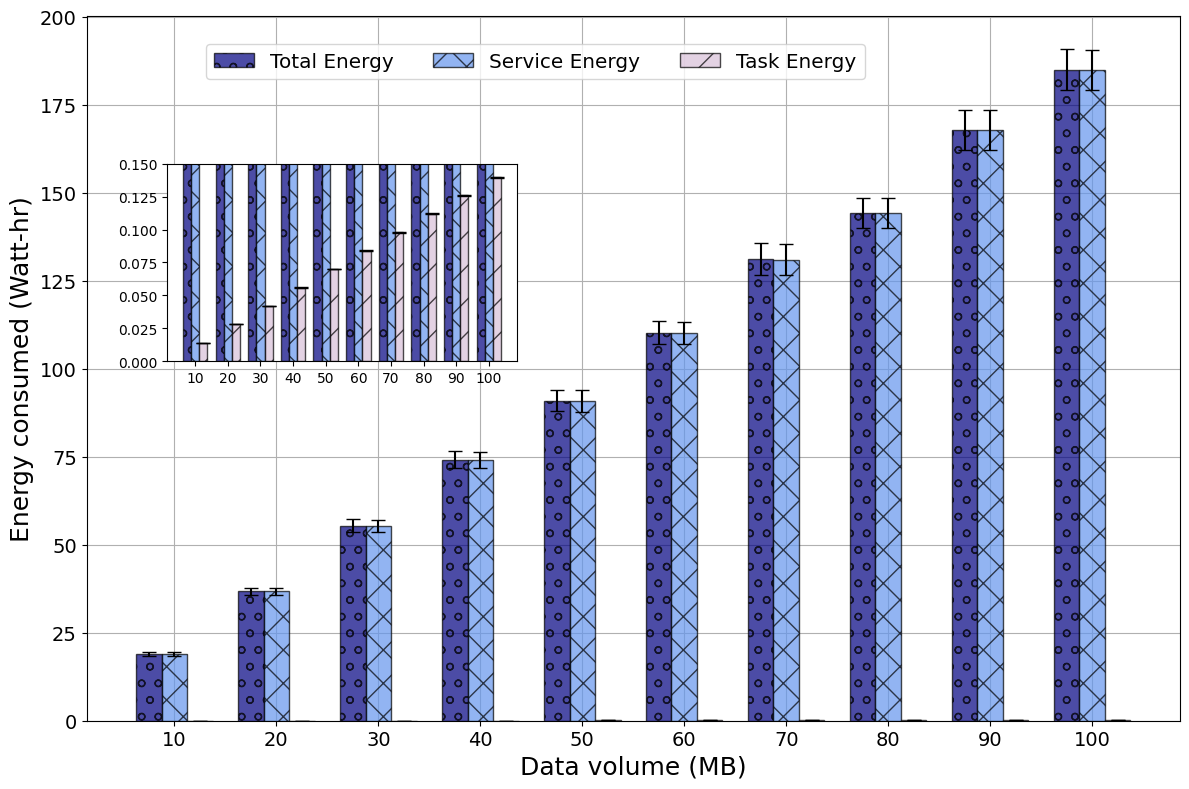

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# plt.rcParams['font.family'] = 'Times New Roman'

# Load the CSV file into a DataFrame
df = pd.read_csv('energy_consumption_data_volume.csv')

# Group the data by data_volume_range
grouped = df.groupby('data_volume_range')

# Initialize lists to store means and confidence intervals
data_volume_range = []
total_energy_means = []
total_energy_cis = []
service_energy_means = []
service_energy_cis = []
task_energy_means = []
task_energy_cis = []

confidence_level = 0.95
num_iterations = 100  # Assuming 100 iterations per group
degrees_freedom = num_iterations - 1

# Calculate means and confidence intervals for each group
for name, group in grouped:
    data_volume_range.append(name)

    total_mean = group['total_energy'].mean()
    total_sem = sem(group['total_energy'])
    total_ci = total_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    service_mean = group['service_energy'].mean()
    service_sem = sem(group['service_energy'])
    service_ci = service_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    task_mean = group['task_energy'].mean()
    task_sem = sem(group['task_energy'])
    task_ci = task_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    total_energy_means.append(total_mean)
    total_energy_cis.append(total_ci)
    service_energy_means.append(service_mean)
    service_energy_cis.append(service_ci)
    task_energy_means.append(task_mean)
    task_energy_cis.append(task_ci)

# Convert to numpy arrays for plotting
data_volume_range = np.array(data_volume_range)
total_energy_means = np.array(total_energy_means)
total_energy_cis = np.array(total_energy_cis)
service_energy_means = np.array(service_energy_means)
service_energy_cis = np.array(service_energy_cis)
task_energy_means = np.array(task_energy_means)
task_energy_cis = np.array(task_energy_cis)

# Plotting bar graph with error bars
fig, ax = plt.subplots(figsize=(12, 8))

width = 0.25  # Width of the bars

# Create bar positions
x = np.arange(len(data_volume_range))
x_total = x - width
x_service = x
x_task = x + width

# Plot bars
ax.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black', zorder=3)
ax.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black', zorder=3)
ax.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black', zorder=3)

# Add labels and title
ax.set_xlabel('Data volume (MB)', fontsize=18)
ax.set_ylabel('Energy consumed (Watt-hr)', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(data_volume_range)

# Set tick size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()

# Create an inset plot
# bbox_to_anchor (x0, y0, width, height) and loc are used for inset position
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(-0.4, 0.1, 0.8, 0.7), bbox_transform=ax.transAxes)
ax_inset.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black', zorder=2)
ax_inset.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black', zorder=2)
ax_inset.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black', zorder=2)

# Set labels, tick size, and ylim for the inset plot
# ax_inset.set_xlabel('Data Volume Range', fontsize=12)
# ax_inset.set_ylabel('Energy (Joules)', fontsize=12)
print(x)
ax_inset.set_xticks(x)
ax_inset.tick_params(axis='both', which='major', labelsize=10)
ax_inset.set_xticklabels(data_volume_range)
ax_inset.set_ylim(0, 0.15)

# Create a single legend for both plots outside the main plot
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize='x-large', bbox_to_anchor=(0.45, 0.95))

plt.tight_layout()
plt.savefig('energy_consumption_vs_data_volume.pdf', format='pdf', bbox_inches='tight')
plt.show()


<ipython-input-26-9be894c9be07>:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[0 1 2 3 4]


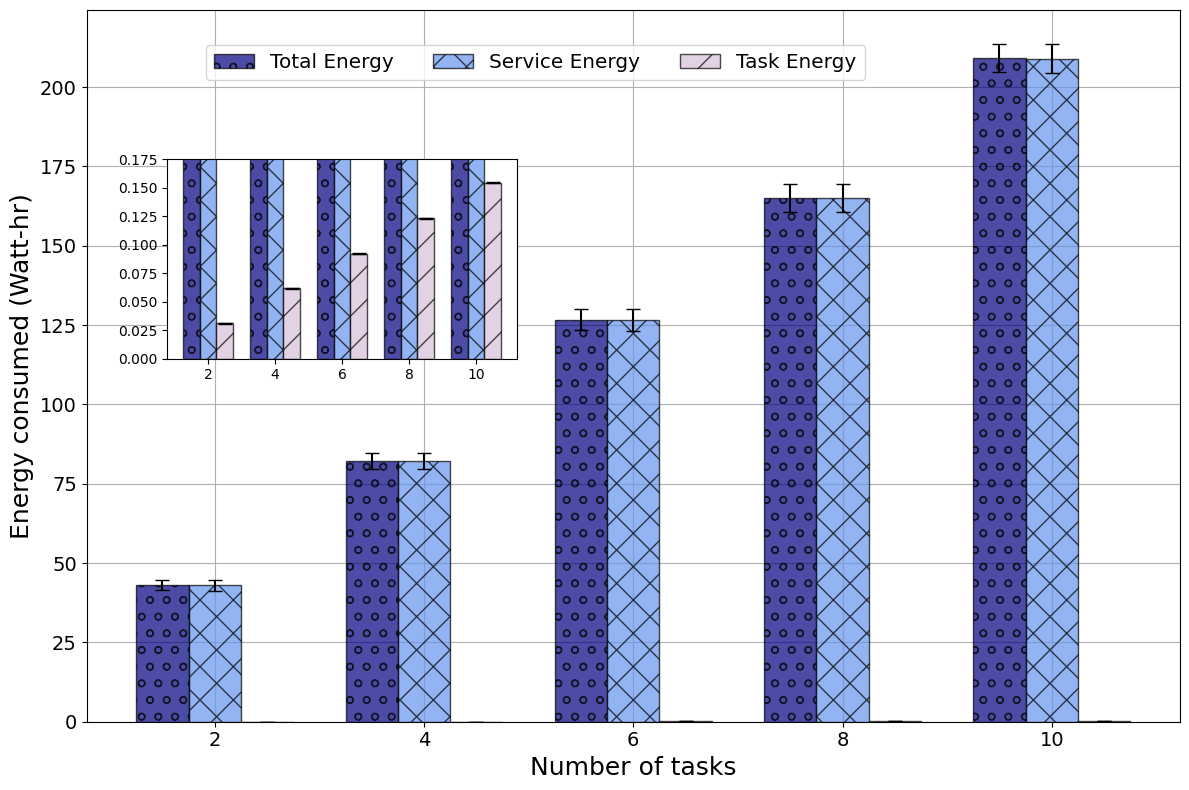

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# plt.rcParams['font.family'] = 'Times New Roman'

# Load the CSV file into a DataFrame
df = pd.read_csv('energy_consumption_num_task.csv')

# Group the data by num_task
grouped = df.groupby('num_task')

# Initialize lists to store means and confidence intervals
num_task = []
total_energy_means = []
total_energy_cis = []
service_energy_means = []
service_energy_cis = []
task_energy_means = []
task_energy_cis = []

confidence_level = 0.95
num_iterations = 100  # Assuming 100 iterations per group
degrees_freedom = num_iterations - 1

# Calculate means and confidence intervals for each group
for name, group in grouped:
    num_task.append(name)

    total_mean = group['total_energy'].mean()
    total_sem = sem(group['total_energy'])
    total_ci = total_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    service_mean = group['service_energy'].mean()
    service_sem = sem(group['service_energy'])
    service_ci = service_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    task_mean = group['task_energy'].mean()
    task_sem = sem(group['task_energy'])
    task_ci = task_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    total_energy_means.append(total_mean)
    total_energy_cis.append(total_ci)
    service_energy_means.append(service_mean)
    service_energy_cis.append(service_ci)
    task_energy_means.append(task_mean)
    task_energy_cis.append(task_ci)

# Convert to numpy arrays for plotting
num_task = np.array(num_task)
total_energy_means = np.array(total_energy_means)
total_energy_cis = np.array(total_energy_cis)
service_energy_means = np.array(service_energy_means)
service_energy_cis = np.array(service_energy_cis)
task_energy_means = np.array(task_energy_means)
task_energy_cis = np.array(task_energy_cis)

# Plotting bar graph with error bars
fig, ax = plt.subplots(figsize=(12, 8))

width = 0.25  # Width of the bars

# Create bar positions
x = np.arange(len(num_task))
x_total = x - width
x_service = x
x_task = x + width

# Plot bars
ax.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black', zorder=3)
ax.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black', zorder=3)
ax.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black', zorder=3)

# Add labels and title
ax.set_xlabel('Number of tasks', fontsize=18)
ax.set_ylabel('Energy consumed (Watt-hr)', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(num_task)

# Set tick size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()

# Create an inset plot
# bbox_to_anchor (x0, y0, width, height) and loc are used for inset position
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(-0.4, 0.1, 0.8, 0.7), bbox_transform=ax.transAxes)
ax_inset.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black')
ax_inset.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black')
ax_inset.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black')

# Set labels, tick size, and ylim for the inset plot
# ax_inset.set_xlabel('Data Volume Range', fontsize=12)
# ax_inset.set_ylabel('Energy (Joules)', fontsize=12)
print(x)
ax_inset.set_xticks(x)
ax_inset.tick_params(axis='both', which='major', labelsize=10)
ax_inset.set_xticklabels(num_task)
ax_inset.set_ylim(0, 0.175)

# Create a single legend for both plots outside the main plot
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize='x-large', bbox_to_anchor=(0.45, 0.95))

plt.tight_layout()
plt.savefig('energy_consumption_vs_num_tasks.pdf', format='pdf', bbox_inches='tight')
plt.show()


<ipython-input-28-3ae45599584d>:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[0 1 2 3 4 5]


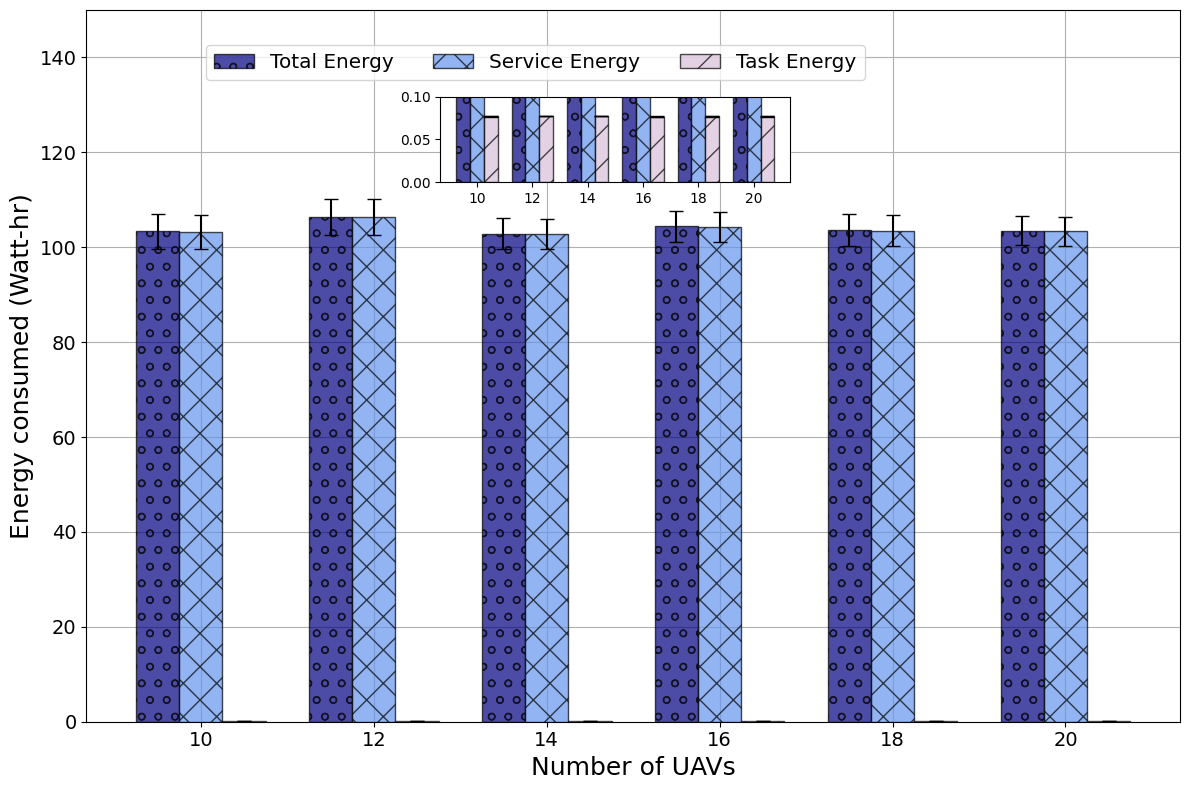

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# plt.rcParams['font.family'] = 'Times New Roman'

# Load the CSV file into a DataFrame
df = pd.read_csv('energy_consumption_num_uav.csv')

# Group the data by num_uav
grouped = df.groupby('num_uav')

# Initialize lists to store means and confidence intervals
num_uav = []
total_energy_means = []
total_energy_cis = []
service_energy_means = []
service_energy_cis = []
task_energy_means = []
task_energy_cis = []

confidence_level = 0.95
num_iterations = 100  # Assuming 100 iterations per group
degrees_freedom = num_iterations - 1

# Calculate means and confidence intervals for each group
for name, group in grouped:
    num_uav.append(name)

    total_mean = group['total_energy'].mean()
    total_sem = sem(group['total_energy'])
    total_ci = total_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    service_mean = group['service_energy'].mean()
    service_sem = sem(group['service_energy'])
    service_ci = service_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    task_mean = group['task_energy'].mean()
    task_sem = sem(group['task_energy'])
    task_ci = task_sem * t.ppf((1 + confidence_level) / 2, degrees_freedom)

    total_energy_means.append(total_mean)
    total_energy_cis.append(total_ci)
    service_energy_means.append(service_mean)
    service_energy_cis.append(service_ci)
    task_energy_means.append(task_mean)
    task_energy_cis.append(task_ci)

# Convert to numpy arrays for plotting
num_uav = np.array(num_uav)
total_energy_means = np.array(total_energy_means)
total_energy_cis = np.array(total_energy_cis)
service_energy_means = np.array(service_energy_means)
service_energy_cis = np.array(service_energy_cis)
task_energy_means = np.array(task_energy_means)
task_energy_cis = np.array(task_energy_cis)

# Plotting bar graph with error bars
fig, ax = plt.subplots(figsize=(12, 8))

width = 0.25  # Width of the bars

# Create bar positions
x = np.arange(len(num_uav))
x_total = x - width
x_service = x
x_task = x + width

# Plot bars
ax.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black', zorder=3)
ax.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black', zorder=3)
ax.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black', zorder=3)

# Add labels and title
ax.set_xlabel('Number of UAVs', fontsize=18)
ax.set_ylabel('Energy consumed (Watt-hr)', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(num_uav)
ax.set_ylim(0, 150)

# Set tick size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()

# Create an inset plot
# bbox_to_anchor (x0, y0, width, height) and loc are used for inset position
ax_inset = inset_axes(ax, width="40%", height="40%", bbox_to_anchor=(-0.15, 0.588, 0.8, 0.3), bbox_transform=ax.transAxes)
ax_inset.bar(x_total, total_energy_means, width, yerr=total_energy_cis, capsize=5, label='Total Energy', alpha=0.7, color='navy', hatch = 'o', edgecolor='black')
ax_inset.bar(x_service, service_energy_means, width, yerr=service_energy_cis, capsize=5, label='Service Energy', alpha=0.7, color='cornflowerblue', hatch = 'x', edgecolor='black')
ax_inset.bar(x_task, task_energy_means, width, yerr=task_energy_cis, capsize=5, label='Task Energy', alpha=0.7, color='thistle', hatch = '/', edgecolor='black')

# Set labels, tick size, and ylim for the inset plot
# ax_inset.set_xlabel('Data Volume Range', fontsize=12)
# ax_inset.set_ylabel('Energy (Joules)', fontsize=12)
print(x)
ax_inset.set_xticks(x)
ax_inset.tick_params(axis='both', which='major', labelsize=10)
ax_inset.set_xticklabels(num_uav)
ax_inset.set_ylim(0, 0.10)

# Create a single legend for both plots outside the main plot
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize='x-large', bbox_to_anchor=(0.45, 0.95))

plt.tight_layout()
plt.savefig('energy_consumption_vs_num_uavs.pdf', format='pdf', bbox_inches='tight')
plt.show()


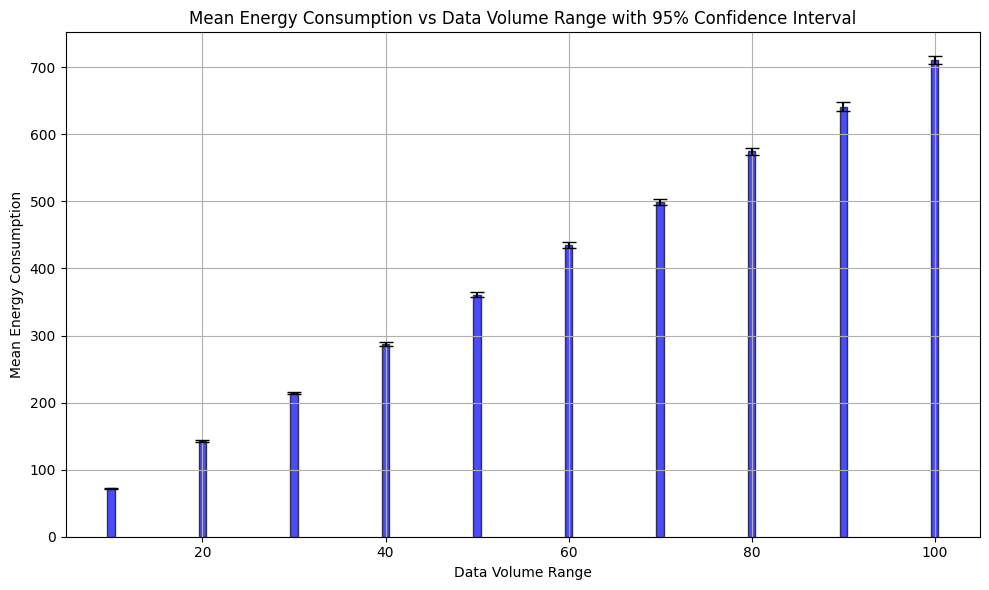

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t

# Assuming final_energy_consumption_array_of_arrays and data_volume_range_array are defined
# For example:
# final_energy_consumption_array_of_arrays = [np.random.rand(100) for _ in range(10)]
# data_volume_range_array = np.linspace(0, 1, 10)

# Number of iterations
num_iterations = len(final_energy_consumption_array_of_arrays[0])

# Calculate mean and 95% confidence interval
means = []
conf_intervals = []

confidence_level = 0.95
degrees_freedom = num_iterations - 1
for array in final_energy_consumption_array_of_arrays:
    mean = np.mean(array)
    means.append(mean)

    standard_error = sem(array)
    confidence_interval = standard_error * t.ppf((1 + confidence_level) / 2, degrees_freedom)
    conf_intervals.append(confidence_interval)

# Convert to numpy arrays for plotting
means = np.array(means)
conf_intervals = np.array(conf_intervals)

# Plotting bar graph with error bars
plt.figure(figsize=(10, 6))
plt.bar(data_volume_range_array, means, yerr=conf_intervals, capsize=5, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Data Volume Range')
plt.ylabel('Mean Energy Consumption')
plt.title('Mean Energy Consumption vs Data Volume Range with 95% Confidence Interval')
plt.grid(True)
plt.tight_layout()
plt.show()


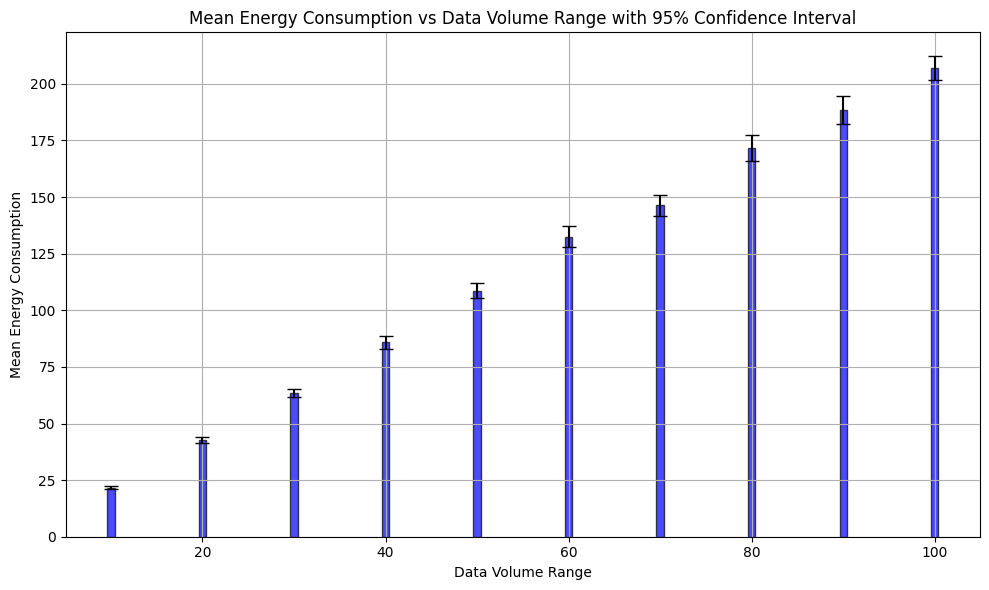

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t

# Assuming final_energy_consumption_array_of_arrays and data_volume_range_array are defined
# For example:
# final_energy_consumption_array_of_arrays = [np.random.rand(100) for _ in range(10)]
# data_volume_range_array = np.linspace(0, 1, 10)

# Number of iterations
num_iterations = len(final_energy_consumption_service_array_of_arrays[0])

# Calculate mean and 95% confidence interval
means = []
conf_intervals = []

confidence_level = 0.95
degrees_freedom = num_iterations - 1
for array in final_energy_consumption_service_array_of_arrays:
    mean = np.mean(array)
    means.append(mean)

    standard_error = sem(array)
    confidence_interval = standard_error * t.ppf((1 + confidence_level) / 2, degrees_freedom)
    conf_intervals.append(confidence_interval)

# Convert to numpy arrays for plotting
means = np.array(means)
conf_intervals = np.array(conf_intervals)

# Plotting bar graph with error bars
plt.figure(figsize=(10, 6))
plt.bar(data_volume_range_array, means, yerr=conf_intervals, capsize=5, alpha=0.7, color='b', edgecolor='black')
plt.xlabel('Data Volume Range')
plt.ylabel('Mean Energy Consumption of service')
plt.title('Mean Energy Consumption vs Data Volume Range with 95% Confidence Interval')
plt.grid(True)
plt.tight_layout()
plt.show()